# LABORATORIO FINAL
# SOLUCIÓN DEL PROBLEMA DE PARQUEADEROS

In [ ]:
# 1. Librerías

# 2. Parámetros del problema

# 3. Simulación

# 4. Estado estable

# 5. Estadísticas por cajero

# 6. Usuarios por tipo

# 7. Estrategia de mejora

# 8. Verificación y validación

# 9. Eliminación del transitorio

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [17]:
# Parámetros del problema

USUARIOS = {
    "rapido": {
        "servicio": 1,
        "llegada": 3,
        "prob": 0.25
    },

    "normal": {
        "servicio": 3,
        "llegada": 3,
        "prob": 0.20
    },

    "lento": {
        "servicio": 4,
        "llegada": 5,
        "prob": 0.275
    },

    "muy_lento": {
        "servicio": 6,
        "llegada": 7,
        "prob": 0.275
    }
}

NUM_CAJEROS = 3

In [18]:
def generar_tipo_usuario():

    r = np.random.random()

    if r < 0.25:
        return "rapido"

    elif r < 0.45:
        return "normal"

    elif r < 0.725:
        return "lento"

    else:
        return "muy_lento"

In [20]:
for i in range(10):
    print(generar_tipo_usuario())

normal
muy_lento
lento
rapido
rapido
lento
rapido
rapido
normal
muy_lento


In [21]:
class Cajero:

    def __init__(self):

        self.tiempo_libre = 0

        self.esperas = []

        self.servicios = []

        self.tiempos_sistema = []

        self.tipos_usuarios = []

In [22]:
cajeros = [
    Cajero(),
    Cajero(),
    Cajero()
]

print("Cantidad de cajeros:", len(cajeros))

Cantidad de cajeros: 3


In [38]:
def simular_sistema(num_usuarios=5000):

    cajeros = [
        Cajero(),
        Cajero(),
        Cajero()
    ]
    esperas_globales = []

    tiempo_global = 0

    for _ in range(num_usuarios):

        tipo = generar_tipo_usuario()

        media_llegada = USUARIOS[tipo]["llegada"]

        media_servicio = USUARIOS[tipo]["servicio"]

        interarribo = np.random.exponential(
            media_llegada
        )

        tiempo_global += interarribo

        servicio = np.random.exponential(
            media_servicio
        )

        indice_cajero = np.random.randint(0, 3)

        cajero = cajeros[indice_cajero]

        inicio_servicio = max(
            tiempo_global,
            cajero.tiempo_libre
        )

        espera = inicio_servicio - tiempo_global

        salida = inicio_servicio + servicio

        tiempo_sistema = espera + servicio

        cajero.tiempo_libre = salida

        cajero.esperas.append(espera)

        esperas_globales.append(espera)

        cajero.servicios.append(servicio)

        cajero.tiempos_sistema.append(
            tiempo_sistema
        )

        cajero.tipos_usuarios.append(tipo)

    return cajeros, esperas_globales

In [41]:
resultado, esperas_globales = simular_sistema()

print("Simulación terminada")

Simulación terminada


In [42]:
print(len(esperas_globales))

5000


In [26]:
for i, cajero in enumerate(resultado):

    print(
        f"Cajero {i+1}:",
        len(cajero.servicios),
        "usuarios"
    )

Cajero 1: 1689 usuarios
Cajero 2: 1628 usuarios
Cajero 3: 1683 usuarios


In [27]:
for i, cajero in enumerate(resultado):

    print(f"\n===== CAJERO {i+1} =====")

    print("Usuarios:", len(cajero.servicios))

    print("Tiempo promedio de atención:",
          round(np.mean(cajero.servicios), 2))

    print("Tiempo promedio de espera:",
          round(np.mean(cajero.esperas), 2))

    print("Tiempo promedio en sistema:",
          round(np.mean(cajero.tiempos_sistema), 2))

    print("Desviación estándar:",
          round(np.std(cajero.servicios, ddof=1), 2))



===== CAJERO 1 =====
Usuarios: 1689
Tiempo promedio de atención: 3.53
Tiempo promedio de espera: 1.55
Tiempo promedio en sistema: 5.08
Desviación estándar: 4.42

===== CAJERO 2 =====
Usuarios: 1628
Tiempo promedio de atención: 3.7
Tiempo promedio de espera: 1.66
Tiempo promedio en sistema: 5.36
Desviación estándar: 4.52

===== CAJERO 3 =====
Usuarios: 1683
Tiempo promedio de atención: 3.48
Tiempo promedio de espera: 1.57
Tiempo promedio en sistema: 5.05
Desviación estándar: 4.35


In [28]:
promedios_atencion = []

for cajero in resultado:

    promedios_atencion.append(
        np.mean(cajero.servicios)
    )

mejor = np.argmin(promedios_atencion)

peor = np.argmax(promedios_atencion)

print("Mejor cajero:", mejor + 1)

print("Peor cajero:", peor + 1)

Mejor cajero: 3
Peor cajero: 2


In [29]:
for i, cajero in enumerate(resultado):

    datos = cajero.servicios

    media = np.mean(datos)

    std = np.std(datos, ddof=1)

    n = len(datos)

    t_critico = stats.t.ppf(
        0.975,
        n - 1
    )

    margen = t_critico * (
        std / np.sqrt(n)
    )

    print(f"\nCAJERO {i+1}")

    print(
        f"IC95%: [{media-margen:.2f}, {media+margen:.2f}]"
    )


CAJERO 1
IC95%: [3.32, 3.74]

CAJERO 2
IC95%: [3.48, 3.92]

CAJERO 3
IC95%: [3.27, 3.69]


In [30]:
for i, cajero in enumerate(resultado):

    print(
        f"Cajero {i+1}:",
        len(cajero.tipos_usuarios)
    )

Cajero 1: 1689
Cajero 2: 1628
Cajero 3: 1683


In [31]:
conteo_global = {
    "rapido": 0,
    "normal": 0,
    "lento": 0,
    "muy_lento": 0
}

for cajero in resultado:

    for tipo in cajero.tipos_usuarios:

        conteo_global[tipo] += 1

conteo_global

{'rapido': 1245, 'normal': 987, 'lento': 1371, 'muy_lento': 1397}

In [33]:
df_tipos = pd.DataFrame({

    "Tipo": conteo_global.keys(),

    "Cantidad": conteo_global.values()

})

df_tipos["Porcentaje"] = (
    df_tipos["Cantidad"] /
    df_tipos["Cantidad"].sum()
) * 100

df_tipos

,Tipo,Cantidad,Porcentaje
0,rapido,1245,24.90
1,normal,987,19.74
2,lento,1371,27.42
3,muy_lento,1397,27.94


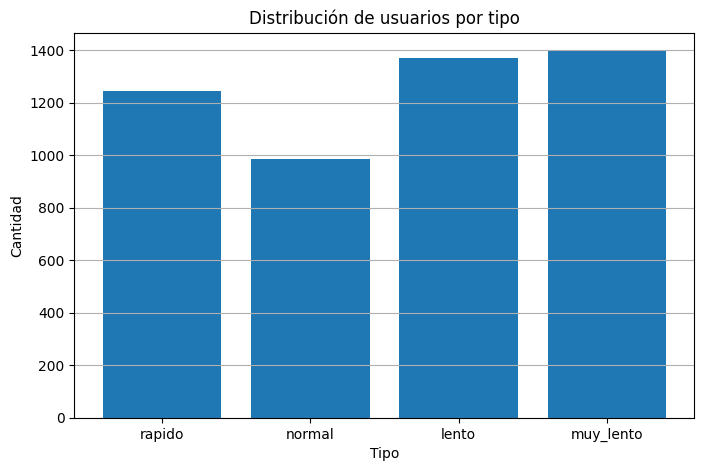

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    df_tipos["Tipo"],
    df_tipos["Cantidad"]
)

plt.title(
    "Distribución de usuarios por tipo"
)

plt.xlabel("Tipo")

plt.ylabel("Cantidad")

plt.grid(axis="y")

plt.show()

In [43]:
ventana = 100

promedios_moviles = []

for i in range(
    len(esperas_globales) - ventana
):

    promedio = np.mean(
        esperas_globales[i:i+ventana]
    )

    promedios_moviles.append(
        promedio
    )

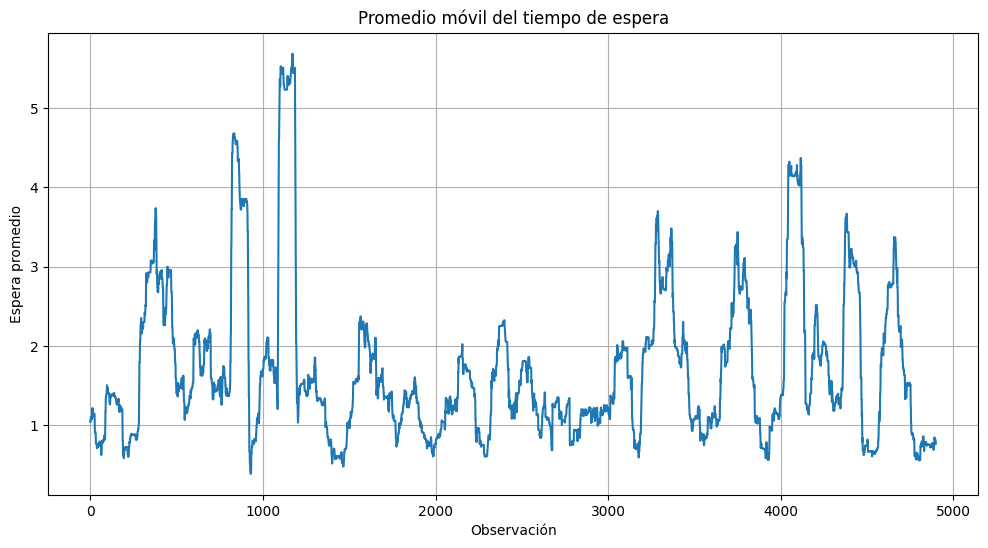

In [44]:
plt.figure(figsize=(12,6))

plt.plot(
    promedios_moviles
)

plt.title(
    "Promedio móvil del tiempo de espera"
)

plt.xlabel(
    "Observación"
)

plt.ylabel(
    "Espera promedio"
)

plt.grid()

plt.show()

In [45]:
punto_corte = 500

esperas_estables = esperas_globales[punto_corte:]

print("Datos originales:",
      len(esperas_globales))

print("Datos estables:",
      len(esperas_estables))

Datos originales: 5000
Datos estables: 4500


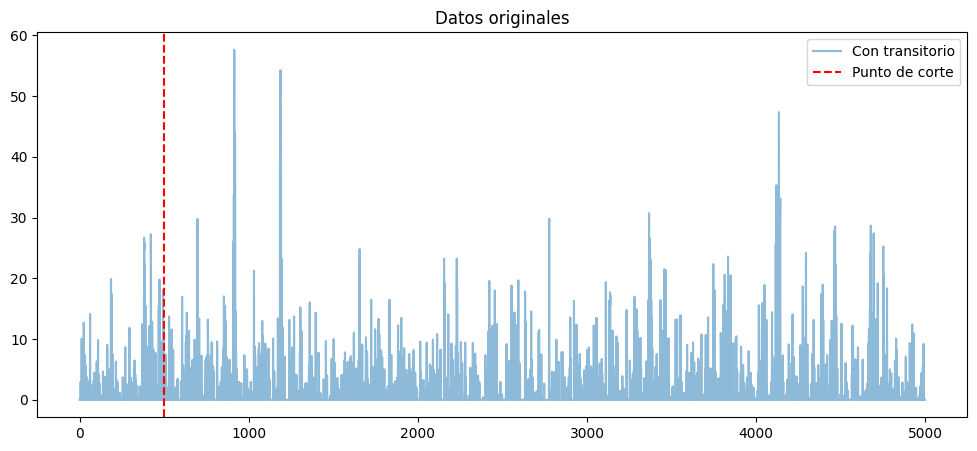

In [46]:
plt.figure(figsize=(12,5))

plt.plot(
    esperas_globales,
    alpha=0.5,
    label="Con transitorio"
)

plt.axvline(
    punto_corte,
    color="red",
    linestyle="--",
    label="Punto de corte"
)

plt.legend()

plt.title(
    "Datos originales"
)

plt.show()

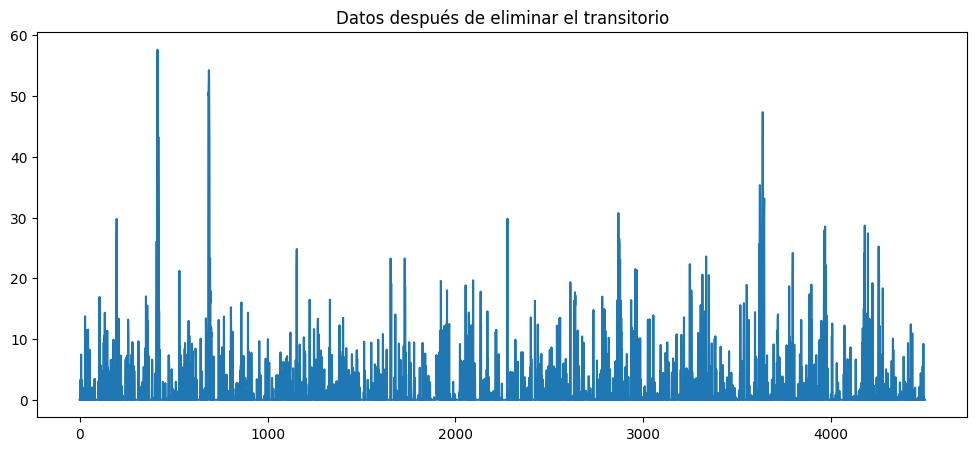

In [47]:
plt.figure(figsize=(12,5))

plt.plot(
    esperas_estables
)

plt.title(
    "Datos después de eliminar el transitorio"
)

plt.show()

In [48]:
def ejecutar_replica():

    resultado, esperas_globales = simular_sistema()

    punto_corte = 500

    esperas_estables = esperas_globales[punto_corte:]

    return np.mean(esperas_estables)

In [49]:
replicas = []

for i in range(30):

    promedio = ejecutar_replica()

    replicas.append(promedio)

print("Réplicas ejecutadas:", len(replicas))

Réplicas ejecutadas: 30


In [50]:
media_global = np.mean(replicas)

std_global = np.std(replicas, ddof=1)

n = len(replicas)

t_critico = stats.t.ppf(0.975, n-1)

margen = t_critico * (
    std_global / np.sqrt(n)
)

print("Media global:", round(media_global,2))

print(
    f"IC95%: [{media_global-margen:.2f}, {media_global+margen:.2f}]"
)

Media global: 1.67
IC95%: [1.61, 1.72]


Los tres cajeros son suficientes

# Punto 4 Verificación
Se verificó el correcto funcionamiento del modelo comprobando que los usuarios fueran asignados aleatoriamente a uno de los tres cajeros, que los tiempos de espera fueran siempre positivos y que el número total de usuarios atendidos coincidiera con el número de usuarios simulados.

#Calibración
Los parámetros del modelo fueron calibrados utilizando los tiempos de llegada y servicio establecidos en el enunciado para cada tipo de usuario. Se verificó además que las proporciones simuladas de usuarios coincidieran con los porcentajes teóricos definidos para cada categoría.

# Validación
La validación del modelo se realizó comparando las proporciones observadas de usuarios con las proporciones teóricas del problema. Los resultados obtenidos presentan diferencias inferiores al 1%, lo que indica que el modelo representa adecuadamente el comportamiento esperado del sistema